In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from torch.optim.lr_scheduler import ReduceLROnPlateau


# =====================================================
# CONFIG
# =====================================================

DATA_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Dataset_crop30_left_top"
OUTPUT_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Basic_CNN_baseline/Outputs/2"
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_cnn.pth")

IMG_SIZE = 224
BATCH_SIZE = 32

EPOCHS = 25

LR = 1e-3
WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 5

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", DEVICE)

# =====================================================
# TRANSFORMS
# =====================================================

train_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.Grayscale(num_output_channels=3),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([

    transforms.Resize((IMG_SIZE, IMG_SIZE)),

    transforms.Grayscale(num_output_channels=3),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# =====================================================
# DATASETS
# =====================================================

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"),
    transform=test_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_DIR, "test"),
    transform=test_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print("\nClasses:", train_dataset.classes)

# =====================================================
# CNN MODEL
# =====================================================

class ChestCNN(nn.Module):

    def __init__(self, num_classes=3):

        super().__init__()

        self.features = nn.Sequential(

            # ------------------
            # BLOCK 1
            # ------------------

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                32,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # ------------------
            # BLOCK 2
            # ------------------

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                64,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2),

            # ------------------
            # BLOCK 3
            # ------------------

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                128,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.MaxPool2d(2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x


model = ChestCNN(
    num_classes=3
).to(DEVICE)

print("\nModel Created.")

# =====================================================
# LOSS
# =====================================================

criterion = nn.CrossEntropyLoss()

# =====================================================
# OPTIMIZER
# =====================================================

optimizer = optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

# =====================================================
# SCHEDULER
# =====================================================

scheduler = ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)


Using Device: cpu

Classes: ['COVID', 'Normal', 'Viral Pneumonia']

Model Created.


In [2]:
# TRAIN FUNCTION

def train_one_epoch():
    model.train()
    running_loss = 0

    for images, labels in tqdm(train_loader):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(
            outputs,
            labels
        )
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    return running_loss / len(train_loader)


# EVALUATION FUNCTION

def evaluate(loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(
                outputs,
                labels
            )
            total_loss += loss.item()
            preds = torch.argmax(
                outputs,
                dim=1
            )
            all_preds.extend(
                preds.cpu().numpy()
            )
            all_labels.extend(
                labels.cpu().numpy()
            )

    acc = accuracy_score(
        all_labels,
        all_preds
    )
    precision = precision_score(
        all_labels,
        all_preds,
        average="weighted"
    )
    recall = recall_score(
        all_labels,
        all_preds,
        average="weighted"
    )
    f1 = f1_score(
        all_labels,
        all_preds,
        average="weighted"
    )

    return (
        total_loss / len(loader),
        acc,
        precision,
        recall,
        f1,
        all_labels,
        all_preds
    )


In [3]:
# TRAINING LOOP


best_val_f1 = 0
counter = 0
train_losses = []
val_losses = []
val_accs = []
val_f1s = []

for epoch in range(EPOCHS):
    train_loss = train_one_epoch()
    (
        val_loss,
        val_acc,
        val_prec,
        val_rec,
        val_f1,
        _,
        _
    ) = evaluate(val_loader)
    
    scheduler.step(val_f1)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accs.append(val_acc)
    val_f1s.append(val_f1)

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")
    print(f"Val Acc    : {val_acc:.4f}")
    print(f"Val Prec   : {val_prec:.4f}")
    print(f"Val Recall : {val_rec:.4f}")
    print(f"Val F1     : {val_f1:.4f}")

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        counter = 0
        torch.save(
            model.state_dict(),
            BEST_MODEL_PATH
        )
        print("Best model saved.")

    else:
        counter += 1
        if counter >= EARLY_STOPPING_PATIENCE:
            print("\nEarly stopping triggered.")
            break


  0%|                                                    | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|███████████████████████████████████████████| 94/94 [05:57<00:00,  3.80s/it]



Epoch 1/25
Train Loss : 0.8465
Val Loss   : 1.8441
Val Acc    : 0.3833
Val Prec   : 0.6621
Val Recall : 0.3833
Val F1     : 0.2606
Best model saved.


  0%|                                                    | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|███████████████████████████████████████████| 94/94 [07:06<00:00,  4.54s/it]



Epoch 2/25
Train Loss : 0.6860
Val Loss   : 0.7907
Val Acc    : 0.6150
Val Prec   : 0.6970
Val Recall : 0.6150
Val F1     : 0.6221
Best model saved.


  0%|                                                    | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|███████████████████████████████████████████| 94/94 [07:03<00:00,  4.51s/it]


...


Epoch 23/25
Train Loss : 0.1959
Val Loss   : 0.2883
Val Acc    : 0.8783
Val Prec   : 0.8840
Val Recall : 0.8783
Val F1     : 0.8781


  0%|                                                    | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|███████████████████████████████████████████| 94/94 [05:06<00:00,  3.27s/it]



Epoch 24/25
Train Loss : 0.1993
Val Loss   : 0.3037
Val Acc    : 0.8867
Val Prec   : 0.8872
Val Recall : 0.8867
Val F1     : 0.8861


  0%|                                                    | 0/94 [00:00<?, ?it/s]/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)
100%|███████████████████████████████████████████| 94/94 [05:16<00:00,  3.37s/it]



Epoch 25/25
Train Loss : 0.1854
Val Loss   : 0.2069
Val Acc    : 0.9283
Val Prec   : 0.9284
Val Recall : 0.9283
Val F1     : 0.9274
Best model saved.



Loading best model...


/opt/miniconda3/envs/ml_env/lib/python3.10/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)



========== TEST RESULTS ==========
Test Loss : 0.1515
Accuracy  : 0.9563
Precision : 0.9566
Recall    : 0.9563
F1 Score  : 0.9561

Classification Report:

                 precision    recall  f1-score   support

          COVID       0.96      0.94      0.95       145
         Normal       0.96      0.92      0.94       145
Viral Pneumonia       0.95      1.00      0.97       145

       accuracy                           0.96       435
      macro avg       0.96      0.96      0.96       435
   weighted avg       0.96      0.96      0.96       435



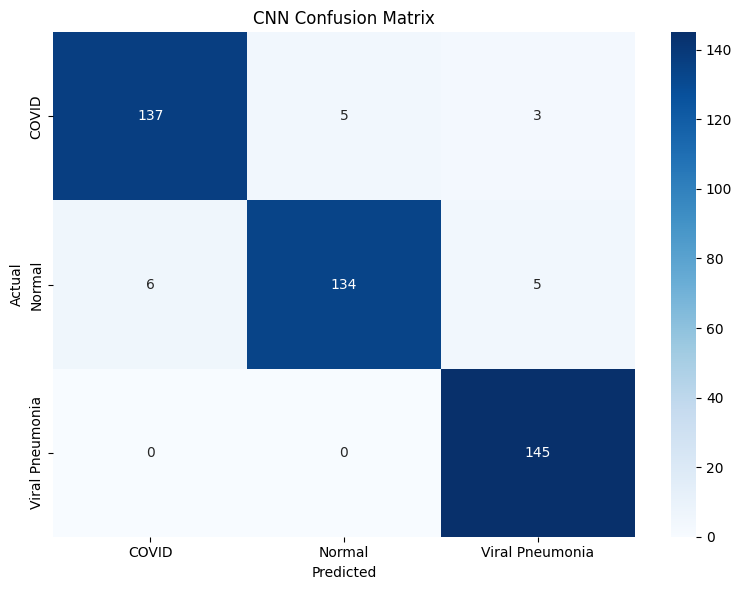

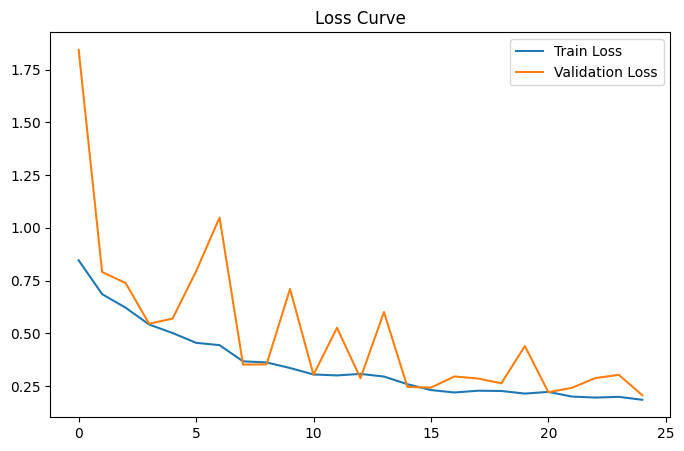

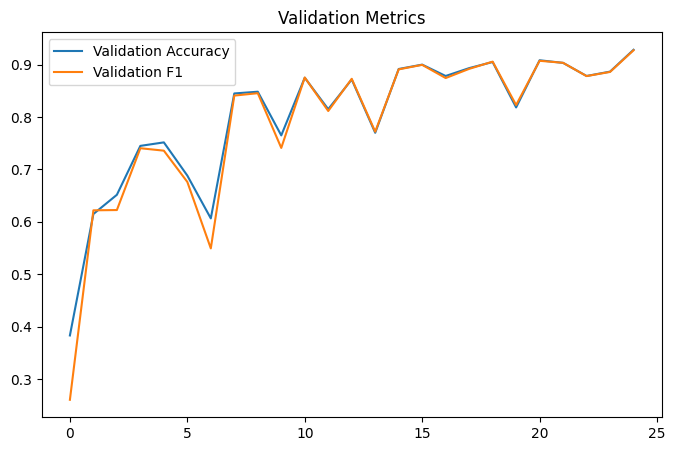

In [4]:
# TESTING

print("\nLoading best model...")
model.load_state_dict(
    torch.load(
        BEST_MODEL_PATH,
        map_location=DEVICE
    )
)

(
    test_loss,
    test_acc,
    test_prec,
    test_rec,
    test_f1,
    all_labels,
    all_preds
) = evaluate(test_loader)

print("\n========== TEST RESULTS ==========")
print(f"Test Loss : {test_loss:.4f}")
print(f"Accuracy  : {test_acc:.4f}")
print(f"Precision : {test_prec:.4f}")
print(f"Recall    : {test_rec:.4f}")
print(f"F1 Score  : {test_f1:.4f}")


# CLASSIFICATION REPORT

print("\nClassification Report:\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=train_dataset.classes
    )
)


# CONFUSION MATRIX

cm = confusion_matrix(
    all_labels,
    all_preds
)
plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("CNN Confusion Matrix")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "cnn_confusion_matrix.png"),
    dpi=300
)
plt.show()


# LOSS CURVE

plt.figure(figsize=(8,5))
plt.plot(
    train_losses,
    label="Train Loss"
)
plt.plot(
    val_losses,
    label="Validation Loss"
)
plt.legend()
plt.title("Loss Curve")
plt.savefig(
    os.path.join(OUTPUT_DIR, "cnn_loss_curve.png"),
    dpi=300
)
plt.show()


# ACCURACY / F1 CURVE

plt.figure(figsize=(8,5))
plt.plot(
    val_accs,
    label="Validation Accuracy"
)
plt.plot(
    val_f1s,
    label="Validation F1"
)
plt.legend()
plt.title("Validation Metrics")
plt.savefig(
    os.path.join(OUTPUT_DIR, "cnn_metrics_curve.png"),
    dpi=300
)
plt.show()

####
# GRAD-CAM

In [10]:
import cv2
import torch
import numpy as np

from PIL import Image
from torchvision import transforms

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

IMG_SIZE = 224
IMG_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/Random_100_cropped"
SAVE_DIR = "/Users/vishrutgupta/Desktop/exCV_COVID/Explainability/2/Basic_CNN_GradCam"
image_dataset = os.listdir(IMG_DIR)

transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    tensor = transform(img).unsqueeze(0)
    rgb_img = np.array(
        img.resize((224,224))
    ) / 255.0
    return tensor, rgb_img


In [13]:
target_layers = [
    model.features[17]
]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

for i in image_dataset:
    image_path = os.path.join(IMG_DIR, i)
    input_tensor, rgb_img = load_image(image_path)
    input_tensor = input_tensor.to(DEVICE)
    
    grayscale_cam = cam(
        input_tensor=input_tensor
    )[0]

    # save saliency maps
    np.save(
        os.path.join(SAVE_DIR, f"saliency_maps/{os.path.splitext(i)[0]}.npy"),
        grayscale_cam
    )
    
    visualization = show_cam_on_image(
        rgb_img,
        grayscale_cam,
        use_rgb=True
    )
    
    save_path = os.path.join(SAVE_DIR, i)
    cv2.imwrite(
        save_path,
        cv2.cvtColor(
            visualization,
            cv2.COLOR_RGB2BGR
        )
    )

print(f"All Grad-Cam images saved successfully.")

All Grad-Cam images saved successfully.
